       Feature       Score
2          Sex  372.405724
1       Pclass  115.031272
6         Fare   63.030764
9      IsAlone   38.353651
7     Embarked   10.259355
5        Parch    5.963464
3          Age    4.353516
4        SibSp    1.110572
8   FamilySize    0.246193
0  PassengerId    0.022285


/tmp/ipykernel_7803/3477131963.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scores_df, x="Score", y="Feature", palette="viridis")


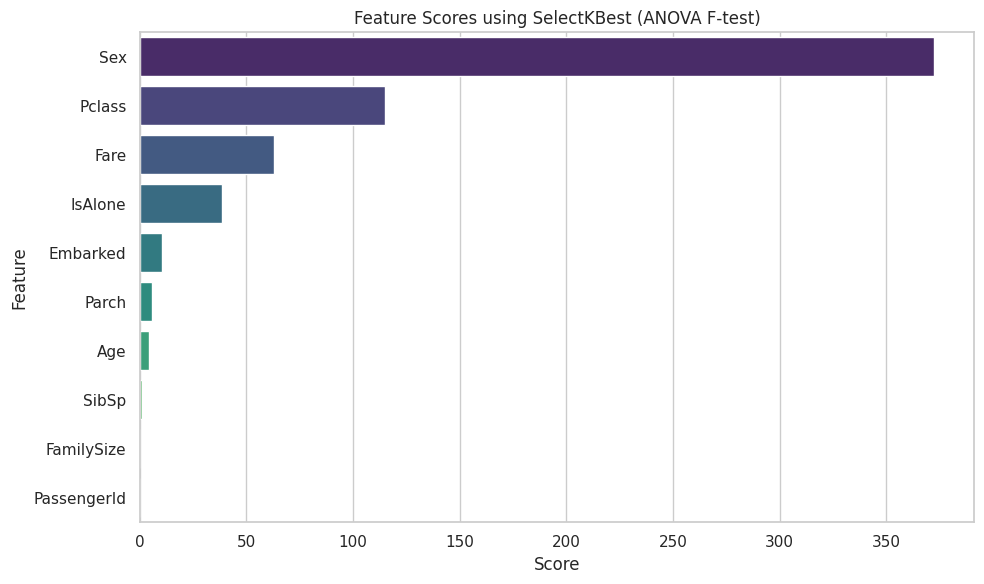

In [3]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling for charts
sns.set(style="whitegrid")

# Load dataset
df = pd.read_csv("../day25-feature-selection-mutual-info/cleaned_titanic.csv")

# Separate features and target
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Apply SelectKBest with ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Create a DataFrame of scores
scores_df = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print(scores_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=scores_df, x="Score", y="Feature", palette="viridis")
plt.title("Feature Scores using SelectKBest (ANOVA F-test)")
plt.tight_layout()
plt.show()
